In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

In [2]:
# Load dataset
df = pd.read_excel(r"C:\Users\User\OneDrive\Documents\Brazilian-Ecommerce-Cleaned.xlsx", parse_dates=[
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
])
print("Done!")

Done!


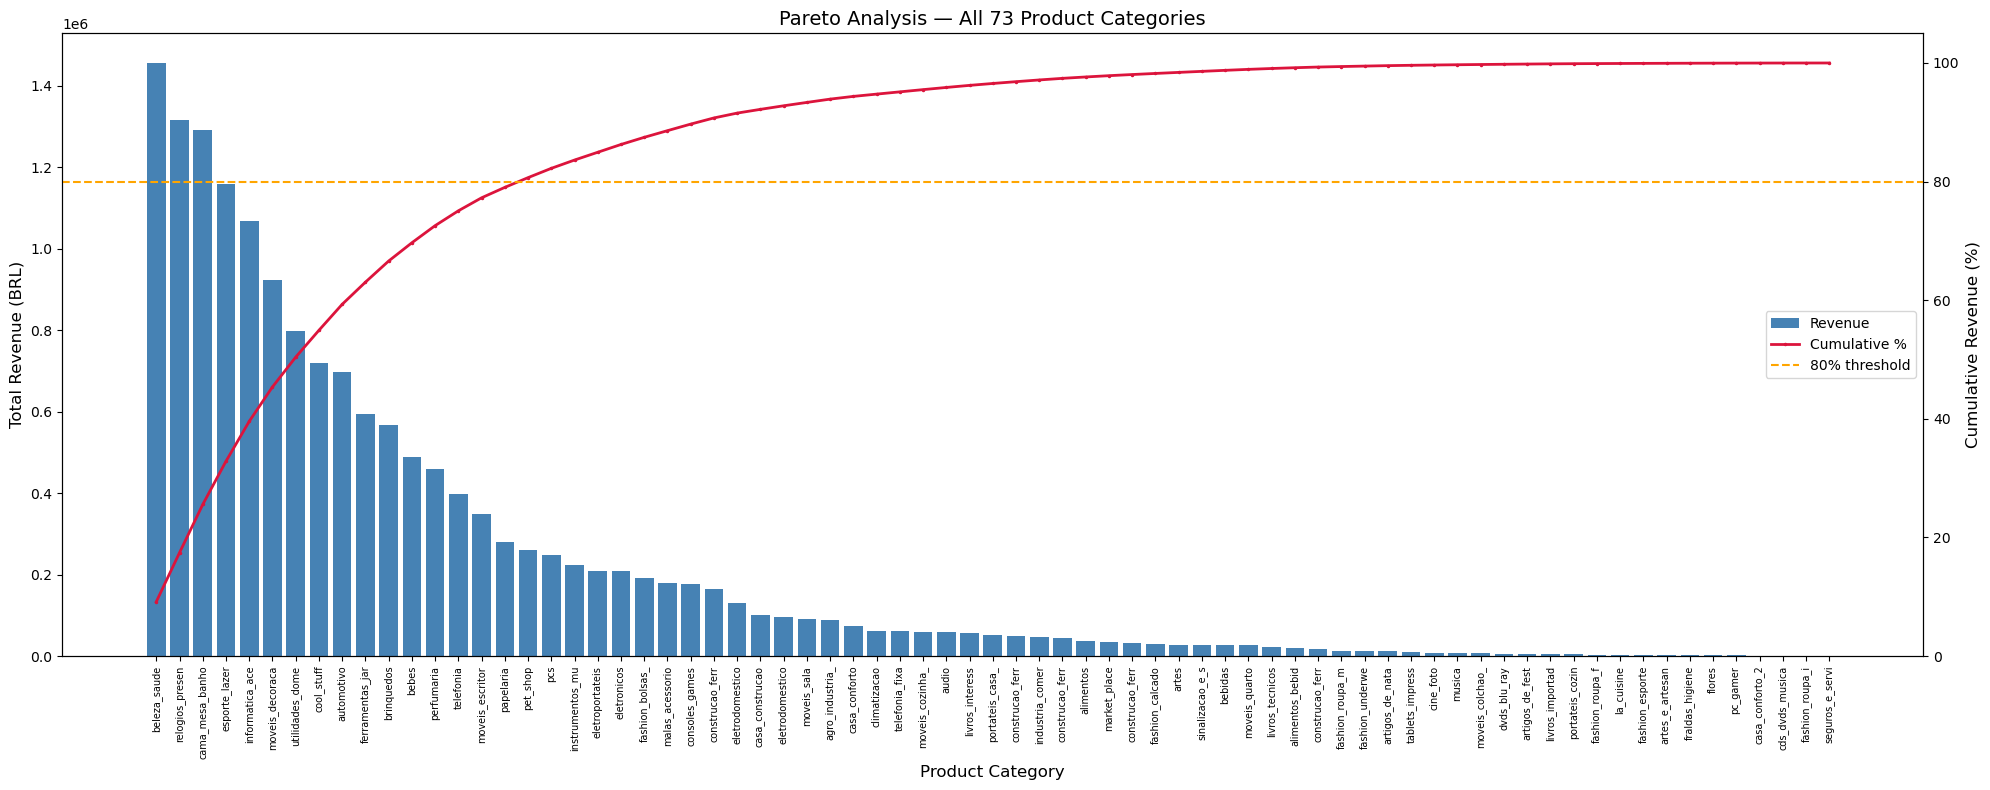

Saved: pareto_analysis.png
    product_category_name   cum_perc
0            beleza_saude   9.159224
1      relogios_presentes  17.430693
2         cama_mesa_banho  25.560059
3           esporte_lazer  32.854437
4  informatica_acessorios  39.576372
RANDOM FOREST CLASSIFIER — MODEL 3 RESULTS
Test Accuracy : 0.4384

Classification Report:
                             precision    recall  f1-score   support

                 automotivo       0.61      0.35      0.45       356
                      bebes       0.46      0.14      0.22       183
               beleza_saude       0.34      0.53      0.41       514
                 brinquedos       0.47      0.11      0.18       272
            cama_mesa_banho       0.46      0.79      0.58       630
                 cool_stuff       0.60      0.27      0.37       151
                eletronicos       0.45      0.25      0.32        87
              esporte_lazer       0.29      0.51      0.37       545
fashion_bolsas_e_acessorios       0.47 

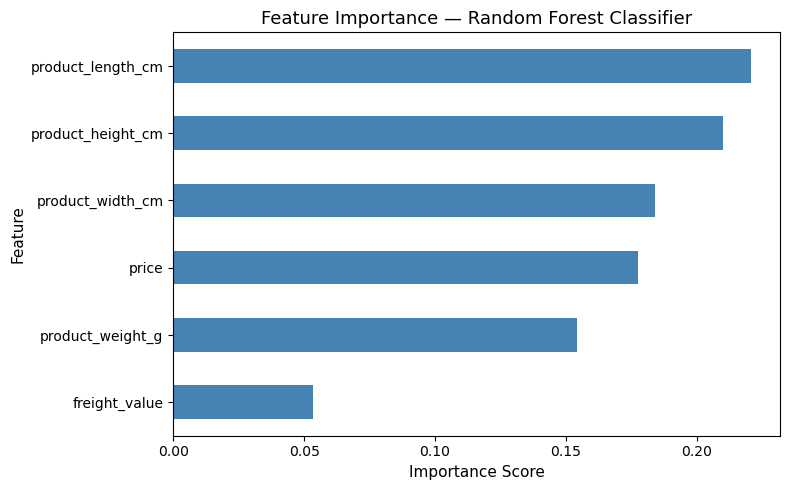

Saved: feature_importance.png


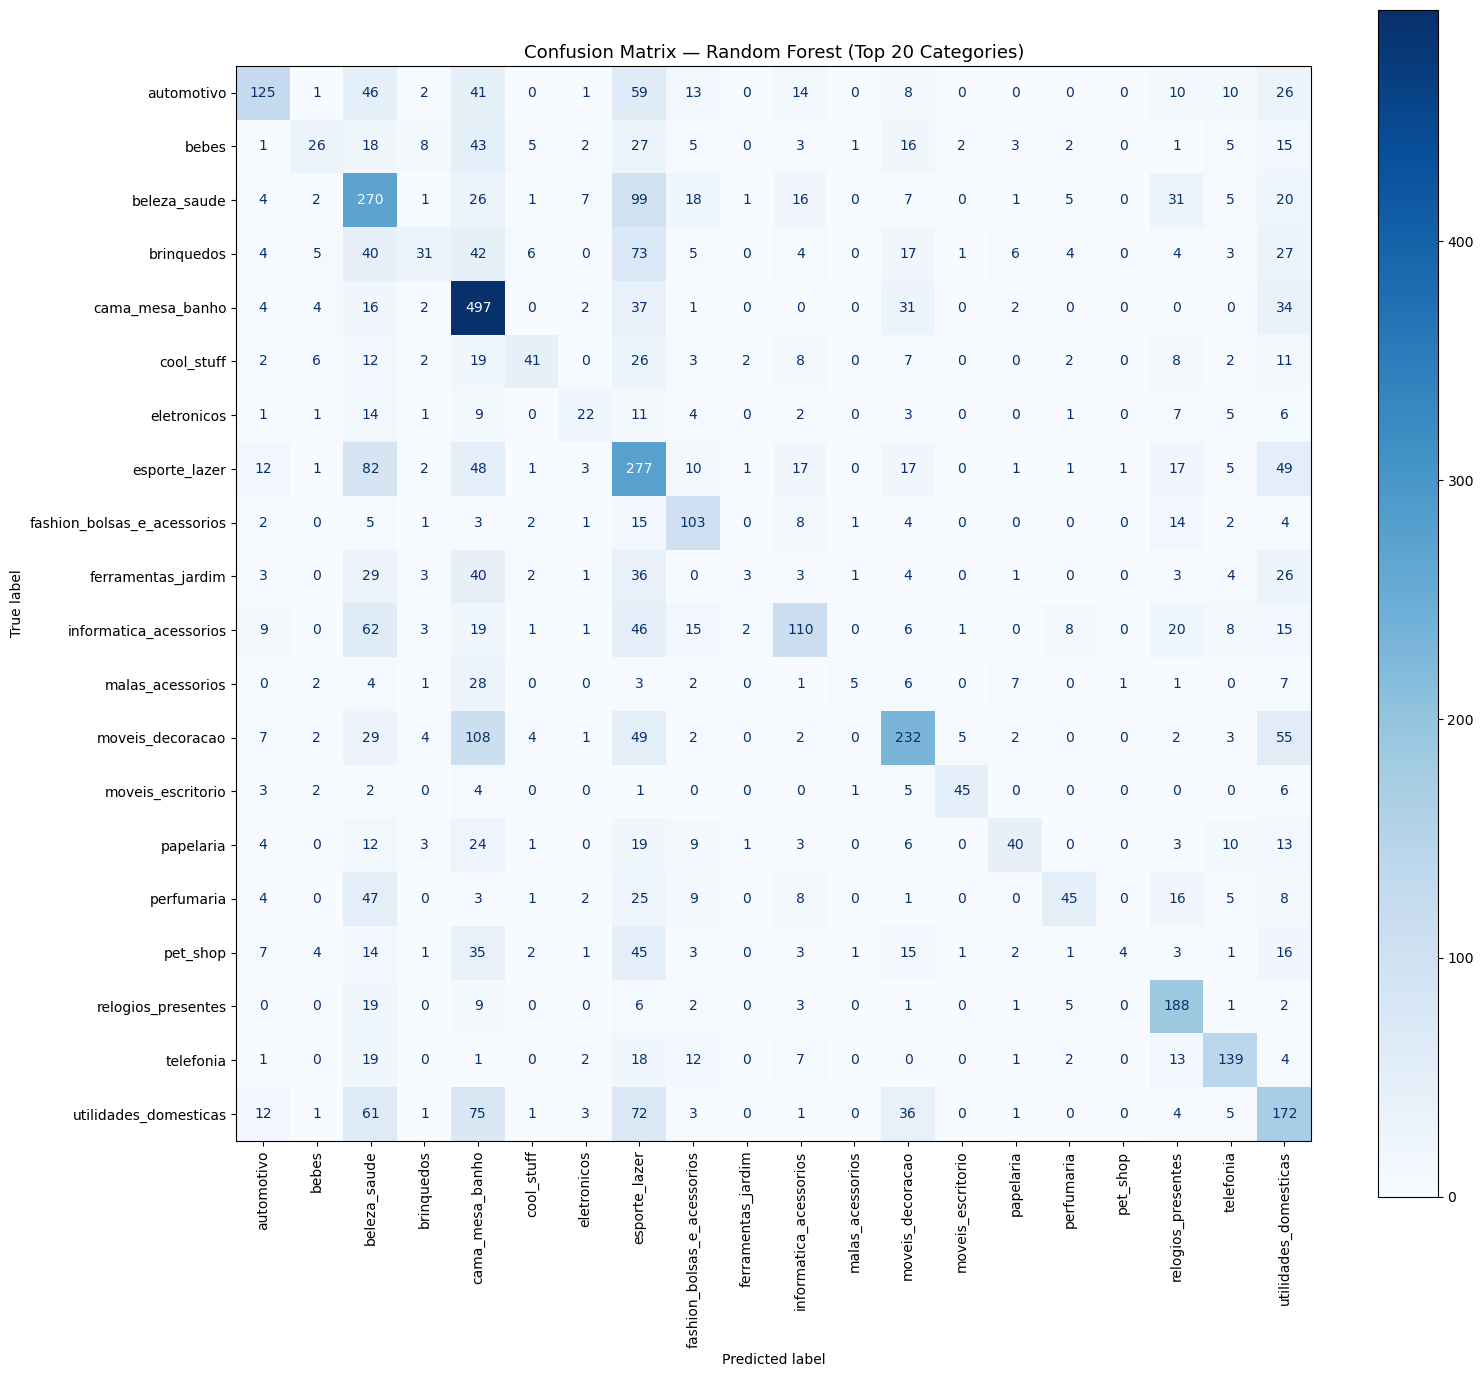

Saved: confusion_matrix.png


In [4]:
# ── OUTPUT DIRECTORY ──────────────────────────────────────────────────────

output_dir = Path(r"D:\Olist_Analysis_Project\Outputs\Module3")
output_dir.mkdir(parents=True, exist_ok=True)

# ── REVENUE COMPUTATION ───────────────────────────────────────────────────

df["revenue"] = df["price"] + df["freight_value"]

category_revenue = (
    df.groupby("product_category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue["cum_perc"] = (
    category_revenue["revenue"].cumsum() /
    category_revenue["revenue"].sum() * 100
)

# ── PARETO CHART (all 73 categories) ─────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(20, 8))

ax1.bar(
    range(len(category_revenue)),
    category_revenue["revenue"],
    color="steelblue",
    label="Revenue"
)
ax1.set_xticks(range(len(category_revenue)))
ax1.set_xticklabels(
    category_revenue["product_category_name"].str[:15],
    rotation=90,
    fontsize=7
)
ax1.set_ylabel("Total Revenue (BRL)", fontsize=12)
ax1.set_xlabel("Product Category", fontsize=12)
ax1.set_title("Pareto Analysis — All 73 Product Categories", fontsize=14)

ax2 = ax1.twinx()
ax2.plot(
    range(len(category_revenue)),
    category_revenue["cum_perc"],
    color="crimson",
    linewidth=2,
    marker=".",
    markersize=3,
    label="Cumulative %"
)

# ── FIX: axhline on ax2 so it aligns with the right axis ─────────────────
ax2.axhline(80, color="orange", linestyle="--", linewidth=1.5, label="80% threshold")
ax2.set_ylabel("Cumulative Revenue (%)", fontsize=12)
ax2.set_ylim(0, 105)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / "pareto_analysis.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: pareto_analysis.png")

# ── VERIFY CUMULATIVE % STARTS CORRECTLY ─────────────────────────────────

print(category_revenue[["product_category_name", "cum_perc"]].head(5))

# ── CLASSIFICATION MODEL ──────────────────────────────────────────────────

top20 = df["product_category_name"].value_counts().head(20).index

df2 = df[df["product_category_name"].isin(top20)].drop_duplicates(subset=[
    "product_id", "product_weight_g", "product_length_cm",
    "product_height_cm", "product_width_cm"
])

X = df2[[
    "product_weight_g", "product_length_cm",
    "product_height_cm", "product_width_cm",
    "price", "freight_value"
]]

y = df2["product_category_name"]

# Group split to prevent data leakage
gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df2["product_id"]))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ── METRICS ───────────────────────────────────────────────────────────────

print("=" * 50)
print("RANDOM FOREST CLASSIFIER — MODEL 3 RESULTS")
print("=" * 50)
print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

# ── FEATURE IMPORTANCE CHART ──────────────────────────────────────────────

imp = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importance — Random Forest Classifier", fontsize=13)
ax.set_xlabel("Importance Score", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
plt.tight_layout()
plt.savefig(output_dir / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: feature_importance.png")

# ── CONFUSION MATRIX ──────────────────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(16, 14))
disp.plot(ax=ax, xticks_rotation=90, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Random Forest (Top 20 Categories)", fontsize=13)
plt.tight_layout()
plt.savefig(output_dir / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")